In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:'%.3f'%x)
sns.set_theme(style="darkgrid")
RANDOM_STATE=42

In [3]:
breast_df=pd.read_csv("breast_cancer_dataset.csv")

In [4]:
breast_df.shape

(569, 32)

In [5]:
df=breast_df.copy()

In [6]:
df.drop(columns=['id'],inplace=True)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [8]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [9]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [10]:
df.value_counts().sum()

np.int64(569)

In [11]:
df['diagnosis'].value_counts(normalize=True)

diagnosis
B   0.627
M   0.373
Name: proportion, dtype: float64

In [12]:
for col in df.columns:
    df[col].value_counts()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(df['diagnosis'].value_counts())
print("-"*30)
print(df['diagnosis'].value_counts(normalize=True))


diagnosis
B    357
M    212
Name: count, dtype: int64
------------------------------
diagnosis
B   0.627
M   0.373
Name: proportion, dtype: float64


In [15]:
df['diagnosis']=df['diagnosis'].map({"B":0,"M":1})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,1,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,1,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,1,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [16]:
df.groupby('diagnosis').mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063,0.284,1.220,2.000,21.135,0.007,0.021,0.026,0.010,0.021,0.004,13.380,23.515,87.006,558.899,0.125,0.183,0.166,0.074,0.270,0.079
1,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063,0.609,1.211,4.324,72.672,0.007,0.032,0.042,0.015,0.020,0.004,21.135,29.318,141.370,1422.286,0.145,0.375,0.451,0.182,0.323,0.092


#### Data Visulatisation

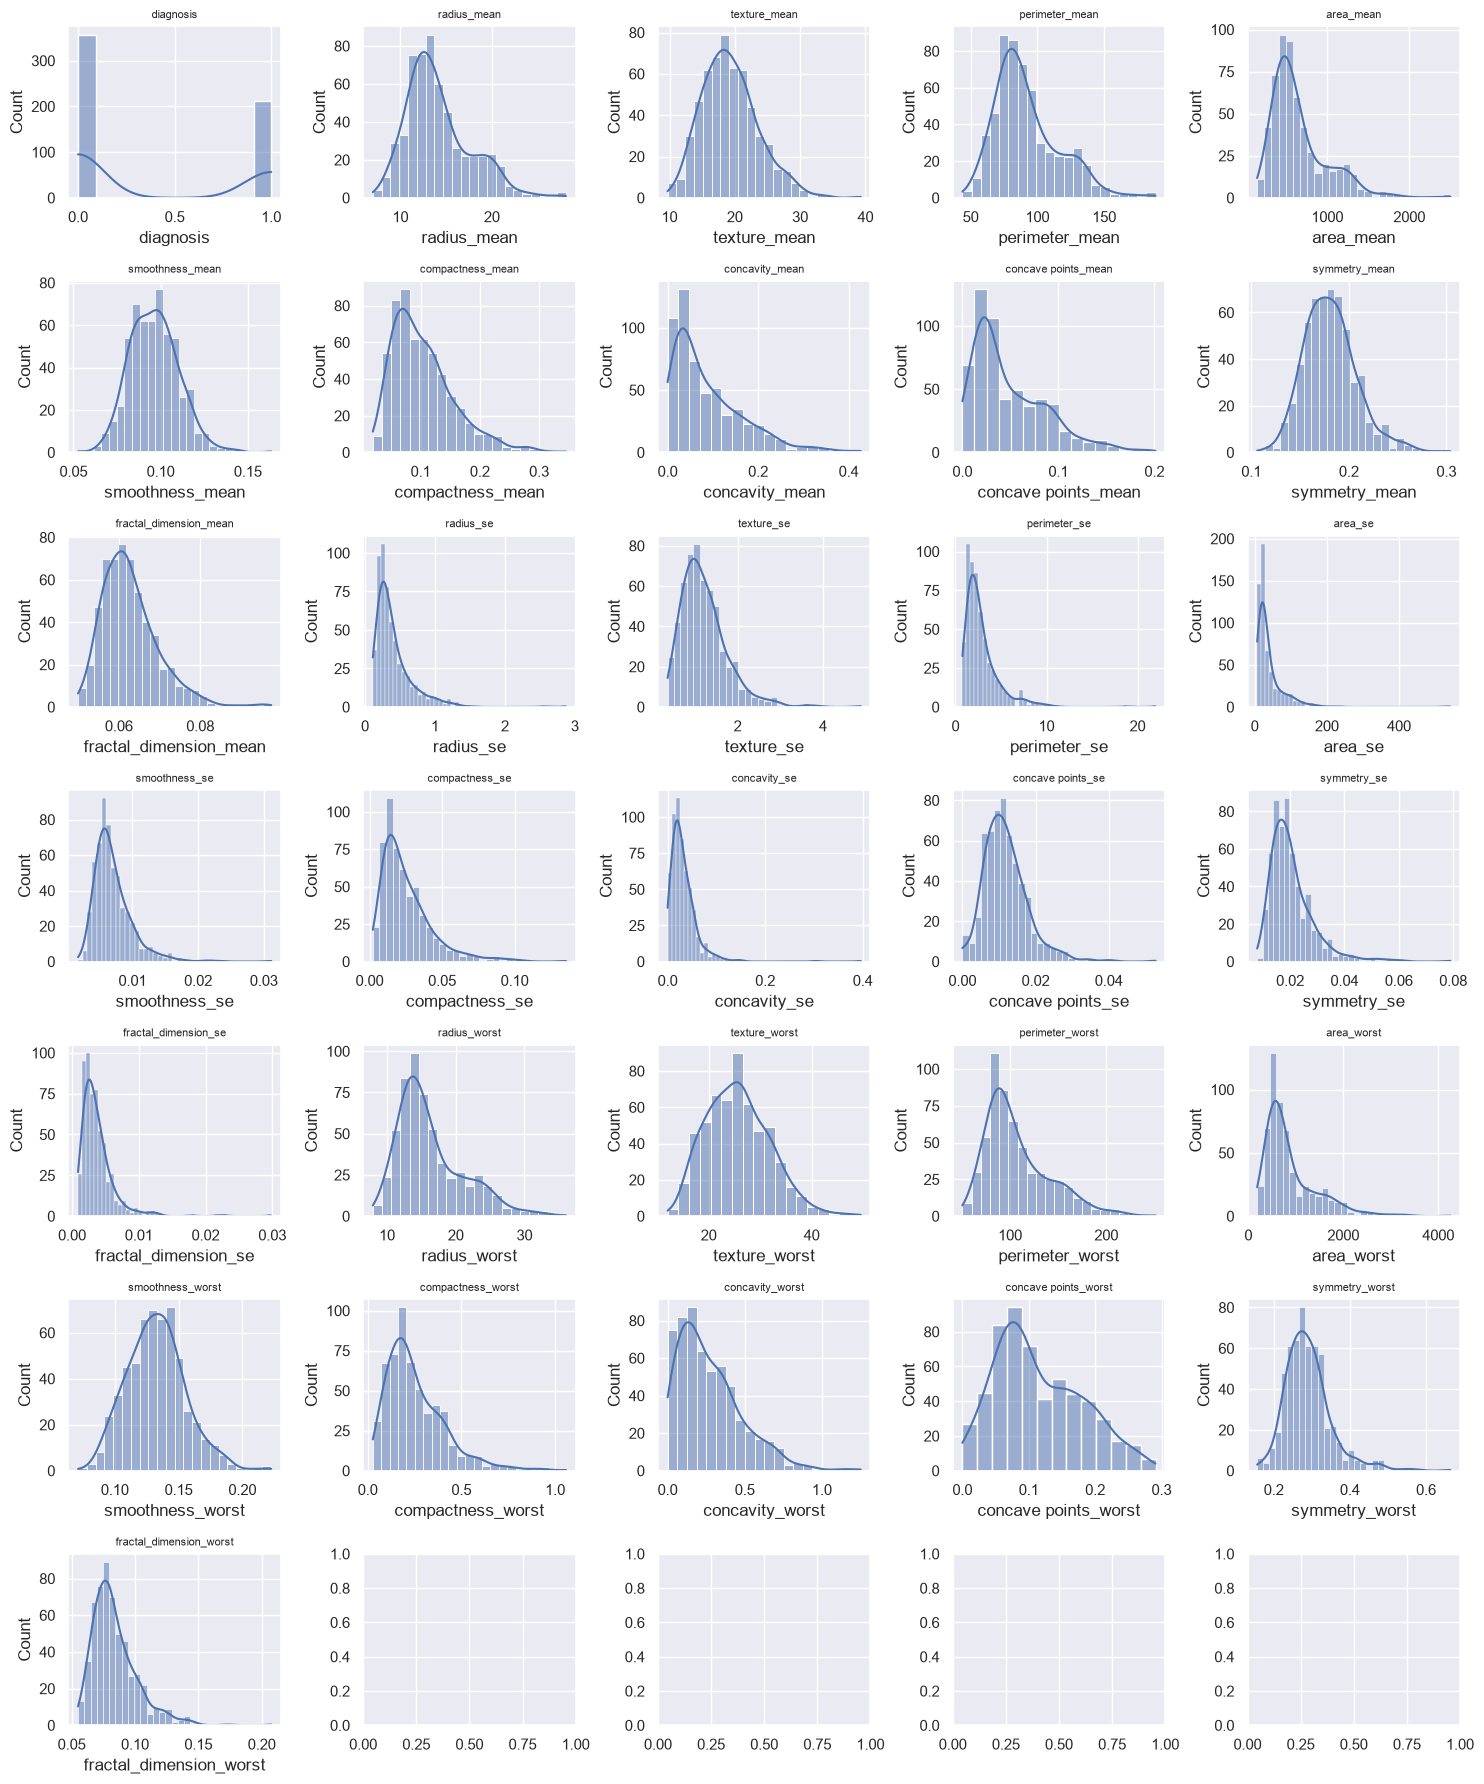

In [17]:
fig,axes=plt.subplots(7,5,figsize=(15,18))
axes=axes.flatten()

for i ,col in enumerate(df.columns):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()
    

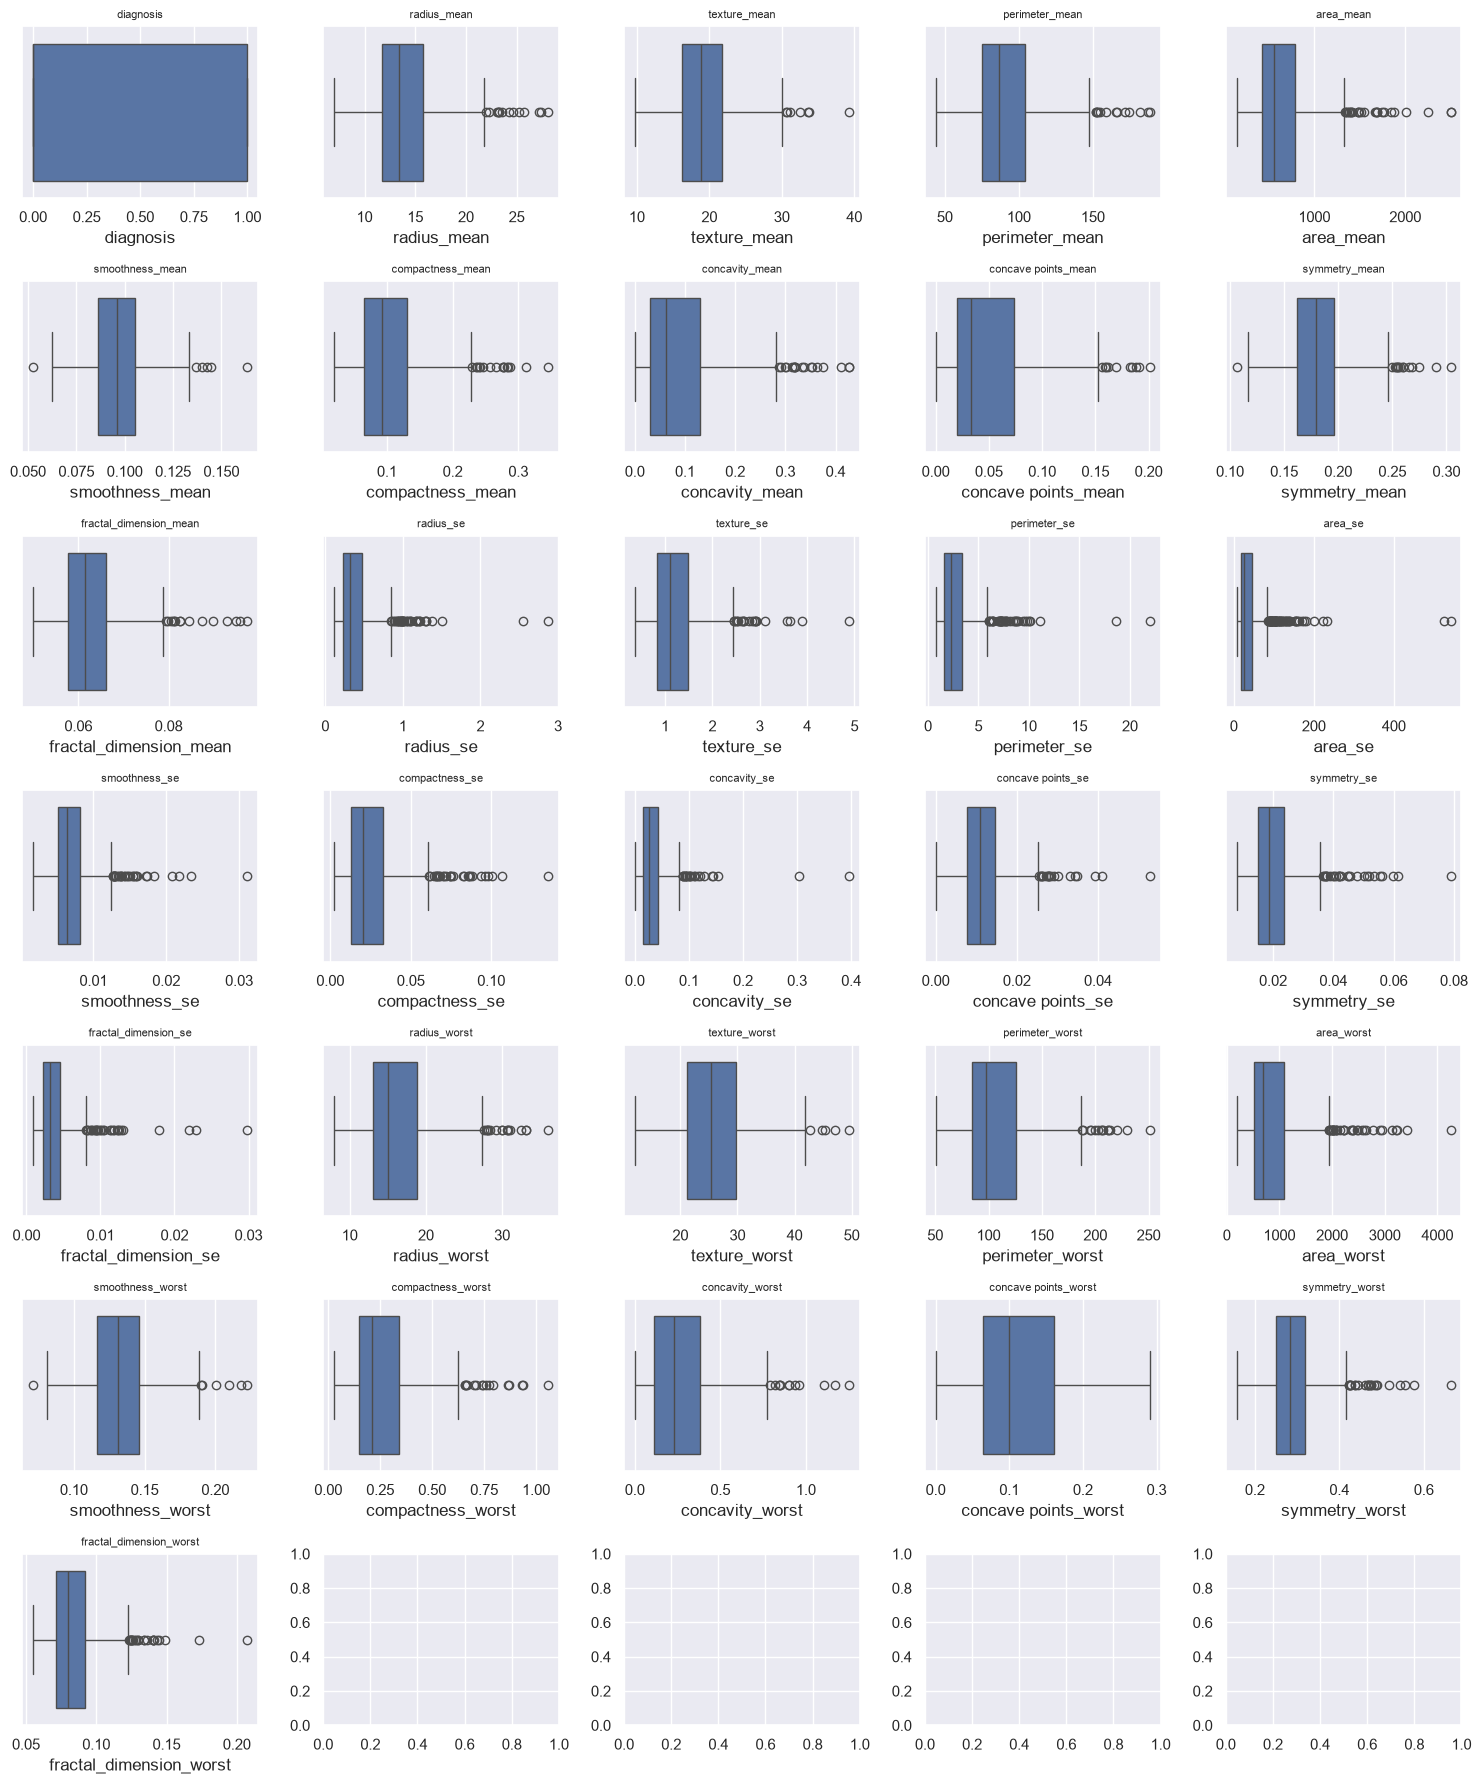

In [18]:
fig,axes=plt.subplots(7,5,figsize=(15,18))
axes=axes.flatten()

for i ,col in enumerate(df.columns):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()
    

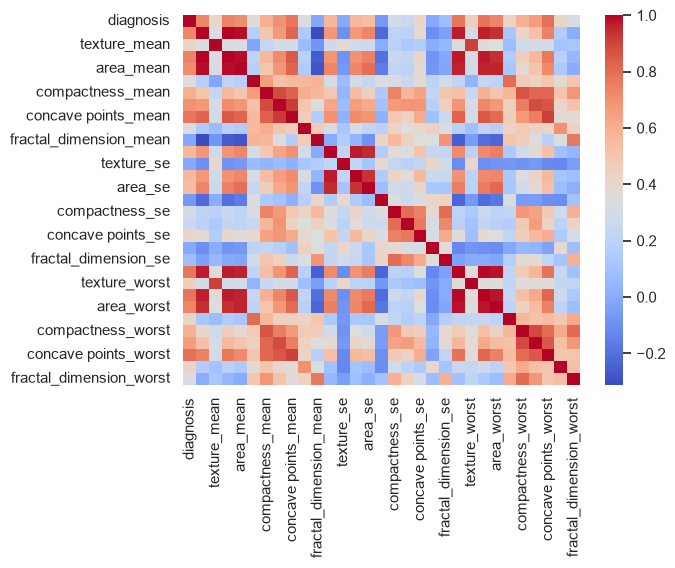

In [19]:
sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

### Data Preprocessing

In [20]:
x=df.drop(columns=['diagnosis'])
y=df['diagnosis']

In [21]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


### Base line model -Logistic Regresssion

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

 

In [25]:
model=LogisticRegression()
model.fit(X_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
#trainig score
model.score(X_train_scaled,y_train)


0.9868131868131869

model.score(X_test_scaled,y_test)
 

### Model optimization

In [28]:
pipeline=Pipeline(
    [
        ("scaler",StandardScaler()),
        ("pca",PCA()),
        ('model',SVC(kernel='rbf'))
    ]
    
)

In [33]:
param_grid=[
    {
        "pca__n_components":[10,15,20,25,30],
        "model__C":[0.001,0.01,0.1,1],
        "model__gamma":[0.001,0.01,0.1,1]
    }
]

In [34]:
k=5
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [35]:
gscv=GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1
    
    
    
)

In [36]:
gscv.fit(X_train,y_train )

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__gamma': [0.001, 0.01, ...], 'pca__n_components': [10, 15, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable add

In [40]:
print("Hperparameter tuning result:")
print("Best params",gscv.best_params_)
print("Good Score:",gscv.best_score_)


Hperparameter tuning result:
Best params {'model__C': 1, 'model__gamma': 0.1, 'pca__n_components': 10}
Good Score: 0.9529411764705882


In [55]:
y_pred=gscv.predict(X_test)
print("\n Test accuracy",accuracy_score(y_test,y_pred))
print("\nconfusion matrix:",confusion_matrix(y_test,y_pred))
print("\n Classifier report: \n",classification_report(y_test,y_pred,digits=4))


 Test accuracy 0.9385964912280702

confusion matrix: [[68  4]
 [ 3 39]]

 Classifier report: 
               precision    recall  f1-score   support

           0     0.9577    0.9444    0.9510        72
           1     0.9070    0.9286    0.9176        42

    accuracy                         0.9386       114
   macro avg     0.9324    0.9365    0.9343       114
weighted avg     0.9390    0.9386    0.9387       114



### Train again with best params

In [46]:
best_pipeline=Pipeline(
    [
        ("sclaer",StandardScaler()),
        ("pca",PCA(n_components=10)),
        ("model",SVC(kernel='rbf',C=1,gamma=0.1))
    ]
)

In [47]:
# train the pipeline
best_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('sclaer', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [51]:
y_train_pred_optimized=best_pipeline.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_train_pred_optimized)*100,2))
confuse=confusion_matrix(y_train,y_train_pred_optimized)
print(f"confusioin Matrix: ",confuse)

Training Accuracy: 98.9
confusioin Matrix:  [[285   0]
 [  5 165]]


<Axes: >

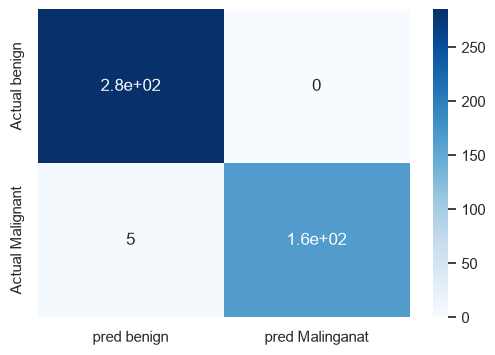

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confuse,
    annot=True,
    cmap="Blues",
    xticklabels=("pred benign","pred Malinganat"),
    yticklabels=("Actual benign","Actual Malignant")
)

In [60]:
y_test_pred=best_pipeline.predict(X_test)
test_acc=accuracy_score(y_test,y_test_pred)
print("Test Accuracy:",(round(test_acc*100)))

Test Accuracy: 95


In [62]:
confuse_test=confusion_matrix(y_test,y_test_pred)
print(confuse_test)

[[68  4]
 [ 2 40]]


<Axes: >

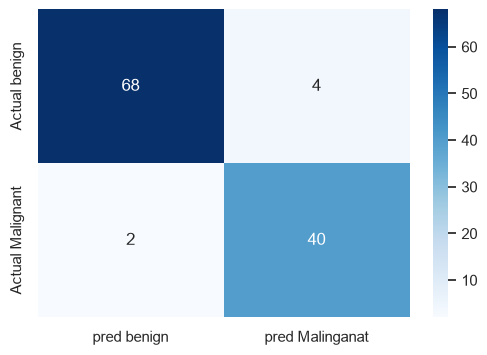

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confuse_test,
    annot=True,
    cmap="Blues",
    xticklabels=("pred benign","pred Malinganat"),
    yticklabels=("Actual benign","Actual Malignant")
)

In [66]:
report=classification_report(y_test,y_test_pred)

In [67]:
report

'              precision    recall  f1-score   support\n\n           0       0.97      0.94      0.96        72\n           1       0.91      0.95      0.93        42\n\n    accuracy                           0.95       114\n   macro avg       0.94      0.95      0.94       114\nweighted avg       0.95      0.95      0.95       114\n'

### Build a predicted System

In [103]:
def predict_cancer(input_features):
    input_df=pd.DataFrame([input_features],columns=X_train.columns)
    pred=best_pipeline.predict(input_df)
    print("Model Prediction",pred)
    if pred[0]==1:
        print("Diagnosis:'🥩Maligant")
    else:
        print("Diagnosis:'🟢baligant")
        
        
     

In [104]:
test_i=y_test.index.tolist()

In [105]:
for idx in test_i:
    predict_cancer(X_test.loc[idx].tolist())


Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [0]
Diagnosis:'🟢baligant
Model Prediction [1]
Diagnosis:'🥩Maligant
Model Prediction [1]
Diagnosis:'🥩M

In [106]:
test=[12.46,24.04,83.97,475.9,0.1186,0.2396,0.2273,0.08543,0.203,0.08243,0.2976,1.599,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.01008,15.09,40.68,97.65,711.4,0.1853,1.058,1.105,0.221,0.4366,0.2075]
predict_cancer(test)


Model Prediction [1]
Diagnosis:'🥩Maligant
